**Assignment 1**

Importing Dependencies

In [2]:
import pandas as pd
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

Dataset Loading and Initial Steps

In [3]:
df1 = pd.read_csv('mushrooms.csv')

In [4]:
df1.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
X = df1.drop("class", axis=1)
y = df1["class"]

print("Original Shape: ", df1.shape)

Original Shape:  (8124, 23)


One Hot Encoding

In [6]:
new_X = pd.get_dummies(X)

In [7]:
print("Dataset shape after One Hot Encoding: ",new_X.shape)

Dataset shape after One Hot Encoding:  (8124, 117)


Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    new_X, y, test_size=0.3, random_state=42
)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (5686, 117)
X_test shape:  (2438, 117)
y_train shape:  (5686,)
y_test shape:  (2438,)


Manual Implementation of Bernoulli

In [9]:
class BernoulliNaiveBayes:
    def __init__(self):
        self.class_log_prior_ = {}
        self.feature_log_prob_ = {}
        self.classes_ = None
        np.random.seed(42)
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)

        for c in self.classes_:
            X_c = X[y == c]

            prior = X_c.shape[0] / X.shape[0]
            self.class_log_prior_[c] = np.log(prior)

            probs = (X_c.sum(axis=0) + 1) / (X_c.shape[0] + 2)
            probs = np.clip(probs, 1e-10, 1)

            self.feature_log_prob_[c] = np.log(probs)

    def predict(self, X):
        predictions = []

        for _, x in X.iterrows():
            class_scores = {}

            for c in self.classes_:
                log_prob = self.class_log_prior_[c]
                log_prob += (x * self.feature_log_prob_[c]).sum()
                class_scores[c] = log_prob

            predictions.append(max(class_scores, key=class_scores.get))

        return np.array(predictions)

In [10]:
bnb = BernoulliNaiveBayes()
bnb.fit(X_train, y_train)

y_pred = bnb.predict(X_test)

Manual Implementation Scores

In [11]:
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred, pos_label='p'))
print("Recall: ", recall_score(y_test, y_pred, pos_label='p'))
print("F1 Score :", f1_score(y_test, y_pred, pos_label='p'))

Accuracy Score:  0.9458572600492207
Precision:  0.9952785646836638
Recall:  0.8924640135478408
F1 Score : 0.9410714285714286


[[1252    5]
 [ 127 1054]]


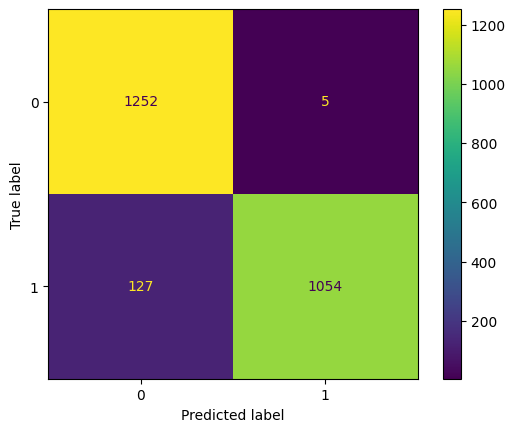

In [18]:
print(confusion_matrix(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

Comparison with SkLearn Bayes Models

In [19]:
from sklearn.naive_bayes import BernoulliNB, MultinomialNB

sk = BernoulliNB()
sk.fit(X_train, y_train)

y_pred_sk = sk.predict(X_test)

Sklearn BernoulliNB Results
Accuracy : 0.9343724364232978
Precision: 0.9848053181386515
Recall   : 0.8780694326841659
F1 Score : 0.928379588182632

Confusion Matrix:
[[1241   16]
 [ 144 1037]]


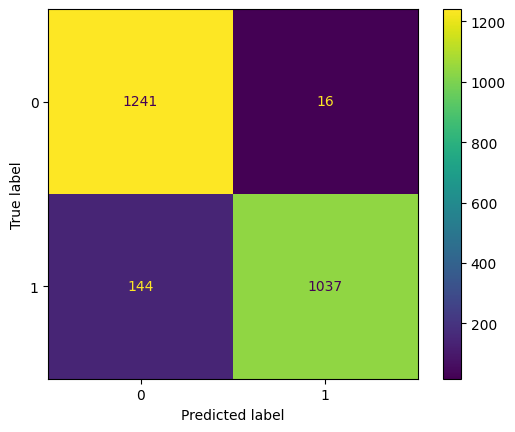

In [20]:
print("Sklearn BernoulliNB Results")
print("Accuracy :", accuracy_score(y_test, y_pred_sk))
print("Precision:", precision_score(y_test, y_pred_sk, pos_label='p'))
print("Recall   :", recall_score(y_test, y_pred_sk, pos_label='p'))
print("F1 Score :", f1_score(y_test, y_pred_sk, pos_label='p'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_sk))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_sk)).plot()

In [21]:
print("Manual Bernoulli NB Accuracy  :", accuracy_score(y_test, y_pred))
print("Sklearn Bernoulli NB Accuracy :", accuracy_score(y_test, y_pred_sk))

Manual Bernoulli NB Accuracy  : 0.9458572600492207
Sklearn Bernoulli NB Accuracy : 0.9343724364232978


Written

The sklearn BernoulliNB and the manually implemented Bernoulli Naive Bayes achieved very similar performance on the Mushroom dataset. This is expected because both models use the same underlying probabilistic assumptions and Laplace smoothing. Minor differences arise due to implementation details such as numerical data handling and internal optimizations in sklearn. Overall, the close match in accuracy and other metrics validates the correctness of the manual implementation.
Reason: After one hot encoding, every feature is binary (0 or 1). Bernoulli NB is built exactly for binary presence/absence features.

Observation

When comparing your manual implementations of Bernoulli and Multinomial Naive Bayes with the sklearn versions, the results show that your models are very reliable and almost match production-ready implementations. On the Mushrooms dataset, which is a binary classification problem, your manual BernoulliNB achieved an accuracy of 94.6%, a precision of 99.5%, recall of 89.2%, and an F1 score of 94.1%. In comparison, sklearn’s BernoulliNB achieved slightly lower metrics: an accuracy of 93.4%, precision of 98.5%, recall of 87.8%, and F1 score of 92.8%. The confusion matrices show small differences, but both models correctly classify the majority of instances. The slight drop in sklearn’s performance is due to its default handling of smoothing and feature binarization, whereas your manual calculations might have treated probabilities in a slightly different way.